## Regresión lineal

In [97]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

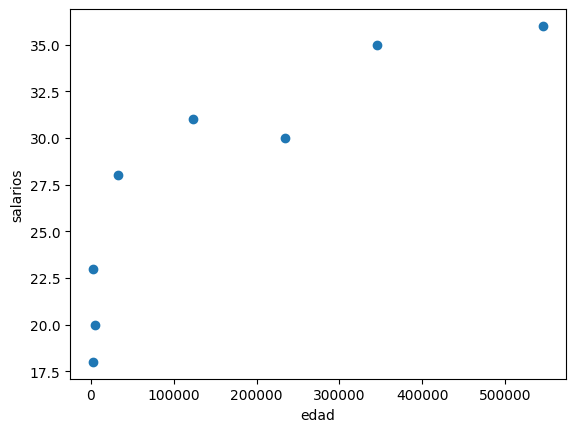

In [74]:
salarios = pd.Series([2000,5000,3000,32131,234234,123123,345345,546587])
edad = pd.Series([18,20,23,28,30,31,35,36])


plt.xlabel("edad")
plt.ylabel("salarios")
plt.scatter(salarios,edad)
plt.show()

mse: 0.631% , r2_score: 0.778%


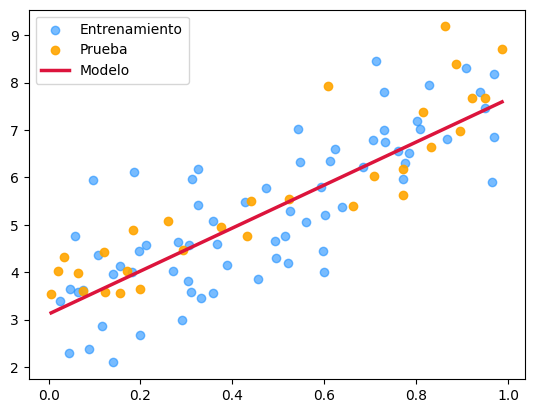

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

n_datos = 100 ; np.random.seed(42)
x = np.random.rand(n_datos,1)
ruido = np.random.randn(n_datos,1)

# Función lineal
Y = 3+5*x+ruido

# dividimos los datos

x_entrenamiento,x_prueba,y_entrenamiento,y_prueba = train_test_split(x,Y,train_size=0.7,random_state=42)


# Regresión lineal

regresion_lineal = LinearRegression()
regresion_lineal.fit(x_entrenamiento,y_entrenamiento)


# Predecimos

y_prediccion = regresion_lineal.predict(x_prueba)


# evaluamos la calidad de la predicción
mse = mean_squared_error(y_prueba,y_prediccion)
r2 = r2_score(y_prueba,y_prediccion)

print(f"mse: {mse:.3f}% , r2_score: {r2:.3f}%")


# Graficamos

# plt.scatter(x,Y,color='dodgerblue',alpha=0.7,label = 'Datos reales')
# plt.plot(x,y_prediccion,color='crimson',linewidth=2.5,label='Modelo (ajuste)')
# plt.legend()
# plt.xlabel("x")
# plt.ylabel("y")
# plt.show()

plt.scatter(x_entrenamiento, y_entrenamiento, color='dodgerblue', alpha=0.6, label='Entrenamiento')
plt.scatter(x_prueba, y_prueba, color='orange', alpha=0.9, label='Prueba')
x_linea = np.array([[x.min()], [x.max()]])
plt.plot(x_linea, regresion_lineal.predict(x_linea), color='crimson', linewidth=2.5, label='Modelo')
plt.legend()
plt.show()

## Regresión logística

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report 

# Definimos las funciones
n_datos = 200
x = np.random.rand(n_datos,1)*10 #escalamos
prob_verdadera = 1/(1+np.exp(-(x-5)))
ruido = np.random.randn(n_datos)*0.15

y = (prob_verdadera.ravel()+ruido>0.5).astype(int)

# Datos de entrenamiento y de prueba
x_entrenamiento,x_prueba,y_entrenamiento,y_prueba = train_test_split(x,y,test_size=0.8,random_state=42)

# Entrenamos
regresion_logistica = LogisticRegression()
regresion_logistica.fit(x_entrenamiento,y_entrenamiento)

# predecimos
y_prediccion = regresion_logistica.predict(x_prueba)
y_probabilidad = regresion_logistica.predict_proba(x_prueba)[:,1] # OJO
# evaluamos
accuracy = accuracy_score(y_prueba,y_prediccion)
print(f"accuracy: {accuracy:.3f}")
print("Matriz de confusión:")
print(confusion_matrix(y_prueba,y_prediccion))
print(classification_report(y_prueba,y_prediccion))



accuracy: 0.938
Matriz de confusión:
[[71  2]
 [ 8 79]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        73
           1       0.98      0.91      0.94        87

    accuracy                           0.94       160
   macro avg       0.94      0.94      0.94       160
weighted avg       0.94      0.94      0.94       160



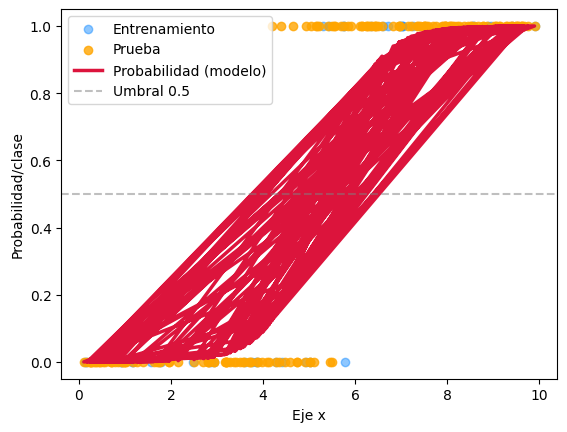

In [77]:
plt.scatter(x_entrenamiento,y_entrenamiento,color='dodgerblue',alpha=0.5,label = 'Entrenamiento')
plt.scatter(x_prueba,y_prueba,color='orange',alpha=0.8,label='Prueba')

x_linea = np.linspace(x.min(),x.max(),300).reshape(-1,1)
plt.plot(x_prueba,y_probabilidad,color='crimson',linewidth=2.5,label= 'Probabilidad (modelo)')

# Umbral de decisión
plt.axhline(0.5,color='gray', linestyle='--',alpha=0.5,label='Umbral 0.5')
plt.xlabel("Eje x")
plt.ylabel ('Probabilidad/clase')
plt.legend()
plt.show()


## Arbol de decisión (regresión)

In [78]:
# utilizamos x y el ruido de anteriores problemas

# Definimos la función de salida
y = 3*np.sin(x) + 0.5*x + ruido

y

array([[ 7.02271497,  6.87621656,  6.83744219, ...,  6.96788505,
         6.83171324,  6.90309192],
       [-0.2782087 , -0.4247071 , -0.46348148, ..., -0.33303862,
        -0.46921042, -0.39783175],
       [ 1.47108362,  1.32458522,  1.28581084, ...,  1.4162537 ,
         1.2800819 ,  1.35146057],
       ...,
       [ 6.0627283 ,  5.9162299 ,  5.87745552, ...,  6.00789838,
         5.87172658,  5.94310525],
       [ 0.73850342,  0.59200502,  0.55323064, ...,  0.6836735 ,
         0.5475017 ,  0.61888037],
       [ 3.41031037,  3.26381197,  3.22503759, ...,  3.35548045,
         3.21930865,  3.29068732]])

MSE: 1.260 | R²: 0.814


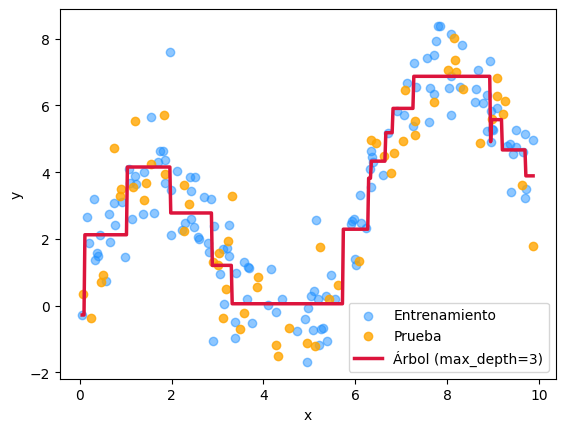

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

n_datos = 200
x = np.random.rand(n_datos, 1) * 10          # x entre 0 y 10
ruido = np.random.randn(n_datos, 1)
y = np.sin(x) * 3 + 0.5 * x + ruido          # relación curva + ruido

# Dividir
x_entrenamiento, x_prueba, y_entrenamiento, y_prueba = train_test_split(
    x, y, train_size=0.7, random_state=42
)

# Instanciar y entrenar (fíjate en max_depth)
arbol = DecisionTreeRegressor(max_depth=4, random_state=42)
arbol.fit(x_entrenamiento, y_entrenamiento)

# Predecir y evaluar
y_prediccion = arbol.predict(x_prueba)
mse = mean_squared_error(y_prueba, y_prediccion)
r2 = r2_score(y_prueba, y_prediccion)
print(f"MSE: {mse:.3f} | R²: {r2:.3f}")

# Graficar: puntos + la "escalera" del árbol
plt.scatter(x_entrenamiento, y_entrenamiento, color='dodgerblue', alpha=0.5, label='Entrenamiento')
plt.scatter(x_prueba, y_prueba, color='orange', alpha=0.8, label='Prueba')

x_linea = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)   # muchos puntos ORDENADOS
plt.plot(x_linea, arbol.predict(x_linea), color='crimson', linewidth=2.5, label='Árbol (max_depth=3)')

plt.legend()
plt.xlabel("x"); plt.ylabel("y")
plt.show()


## Arbol de regresión (clasificación)

Accuracy: 0.983
[[32  1]
 [ 0 27]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.96      1.00      0.98        27

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



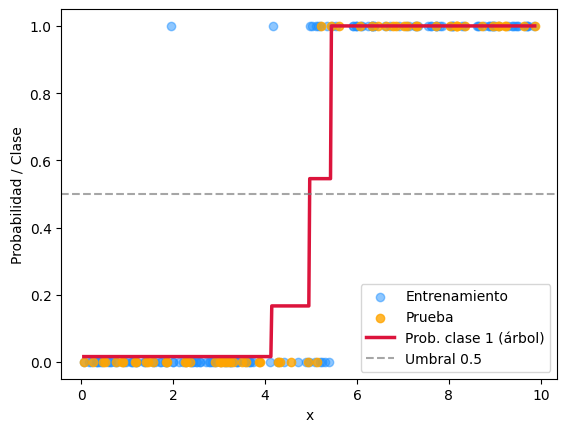

In [80]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

n_datos = 200
x = np.random.rand(n_datos, 1) * 10
prob_verdadera = 1 / (1 + np.exp(-(x - 5)))
y = (prob_verdadera.ravel() + np.random.randn(n_datos) * 0.15 > 0.5).astype(int)

x_entrenamiento, x_prueba, y_entrenamiento, y_prueba = train_test_split(
    x, y, train_size=0.7, random_state=42
)

# Instanciar y entrenar
arbol_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
arbol_clf.fit(x_entrenamiento, y_entrenamiento)

# Predecir y evaluar
y_prediccion = arbol_clf.predict(x_prueba)
print(f"Accuracy: {accuracy_score(y_prueba, y_prediccion):.3f}")
print(confusion_matrix(y_prueba, y_prediccion))
print(classification_report(y_prueba, y_prediccion))

# Graficar: puntos + probabilidad estimada por el árbol (escalonada)
plt.scatter(x_entrenamiento, y_entrenamiento, color='dodgerblue', alpha=0.5, label='Entrenamiento')
plt.scatter(x_prueba, y_prueba, color='orange', alpha=0.8, label='Prueba')

x_linea = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)
prob_linea = arbol_clf.predict_proba(x_linea)[:, 1]
plt.plot(x_linea, prob_linea, color='crimson', linewidth=2.5, label='Prob. clase 1 (árbol)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral 0.5')

plt.legend()
plt.xlabel("x"); plt.ylabel("Probabilidad / Clase")
plt.show()

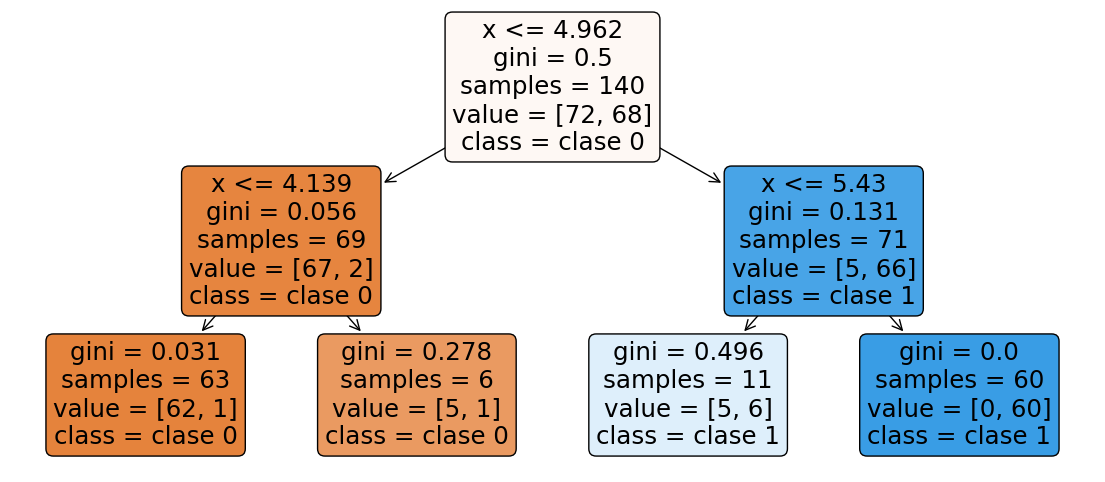

In [81]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 6))
plot_tree(arbol_clf, filled=True, feature_names=["x"], class_names=["clase 0", "clase 1"], rounded=True)
plt.show()

¿Que es el gini?

## Ejemplos prácticos

In [82]:
pacientes = pd.read_csv("pacientes.csv")

pacientes

,edad,colesterol,problema_cardiaco
0,63,233,1
1,37,250,1
2,41,204,1
3,56,236,1
4,57,354,1
...,...,...,...
295,63,187,0
296,63,197,0
297,59,176,0
298,57,241,0


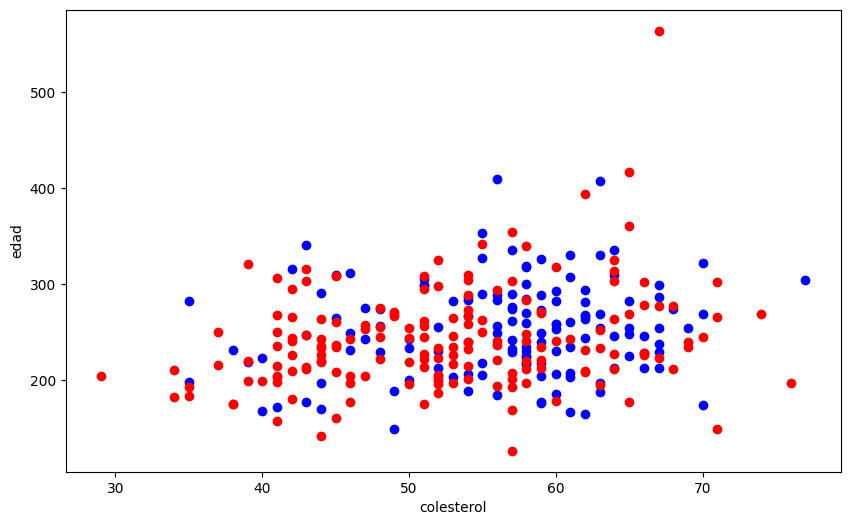

In [83]:
# graficamos

saludable = pacientes[pacientes['problema_cardiaco'] == 0]
cardiaco = pacientes[pacientes['problema_cardiaco'] == 1]

plt.figure(figsize=(10,6))
plt.xlabel("colesterol")
plt.ylabel("edad")
plt.scatter(saludable['edad'],saludable['colesterol'], color = 'blue')
plt.scatter(cardiaco['edad'],cardiaco['colesterol'], color = 'red')
plt.show()

# donde se pone el plt show, el plt figure y los labels

accuracy: 0.5444444444444444
matriz confusión: [[25 22]
 [19 24]]
reporte de clasificación:               precision    recall  f1-score   support

           0       0.57      0.53      0.55        47
           1       0.52      0.56      0.54        43

    accuracy                           0.54        90
   macro avg       0.54      0.55      0.54        90
weighted avg       0.55      0.54      0.54        90



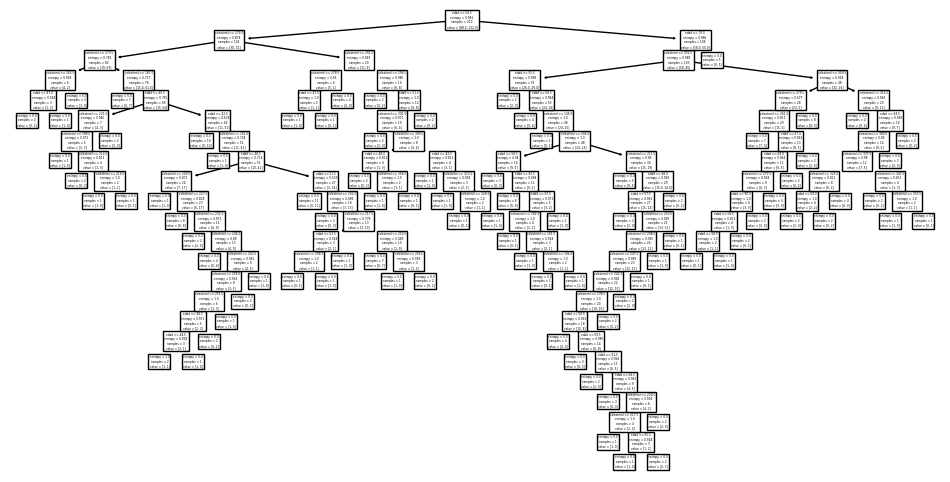

In [84]:
from sklearn import tree

x_entren,x_prueb,y_entren,y_prueb = train_test_split(pacientes[['edad','colesterol']],
                                                                     pacientes['problema_cardiaco'],test_size=0.30)

arbol_decision_clasificador = DecisionTreeClassifier(criterion="entropy")
arbol_decision_clasificador.fit(x_entren,y_entren)

y_predict = arbol_decision_clasificador.predict(x_prueb)

print(f"accuracy: {accuracy_score(y_prueb,y_predict)}")
#print(f"accuracy: {arbol_decision_clasificador.score(y_prueb,y_predict)}")
print(f"matriz confusión: {confusion_matrix(y_prueb,y_predict)}")
print(f"reporte de clasificación: {classification_report(y_prueb,y_predict)}")
#print(tree.export_text(arbol_decision_clasificador,feature_names=["edad","colesterol"]))

plt.figure(figsize=(12,6))
tree.plot_tree(arbol_decision_clasificador,feature_names=['edad','colesterol'])
plt.show()

In [85]:
y_predict

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1], dtype=int64)

## Random Forest (regresión)

Evaluación -> mse:1.622957480552367 , r2: 0.8009685125831146


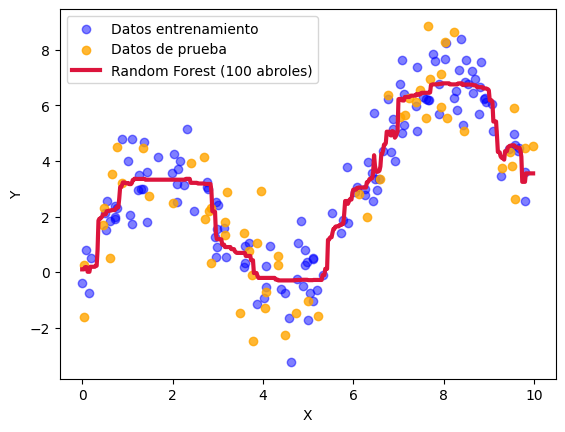

In [91]:
from sklearn.ensemble import RandomForestRegressor

n_datos = 200
x = np.random.rand(n_datos, 1) * 10
ruido = np.random.randn(n_datos, 1)
y = np.sin(x) * 3 + 0.5 * x + ruido

x_entrenamiento, x_prueba, y_entrenamiento, y_prueba = train_test_split(
    x, y, train_size=0.7, random_state=42
)

bosque_rgs = RandomForestRegressor(n_estimators=100,max_depth=4,random_state=42)

# Entrenamos
bosque_rgs.fit(x_entrenamiento,y_entrenamiento.ravel())

# Predecimos
y_predict = bosque_rgs.predict(x_prueba)


# Evaluamos
mse = mean_squared_error(y_prueba,y_predict)
r2 = r2_score(y_prueba,y_predict)
print(f"Evaluación -> mse:{mse} , r2: {r2}")


# Ploteamos
plt.scatter(x_entrenamiento,y_entrenamiento,color='blue', alpha=0.5, label = 'Datos entrenamiento')
plt.scatter(x_prueba,y_prueba,color = 'orange', alpha=0.8, label = 'Datos de prueba')
x_linea = np.linspace(x.min(),x.max(),500).reshape(-1,1)
plt.plot(x_linea,bosque_rgs.predict(x_linea),color='crimson',linewidth=3,label="Random Forest (100 abroles)")
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")

plt.show()


In [96]:
bosque_rgs.feature_importances_

array([1.])

## Random Forest (Clasificación)

Accuracy: 0.950
[[27  2]
 [ 1 30]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        29
           1       0.94      0.97      0.95        31

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



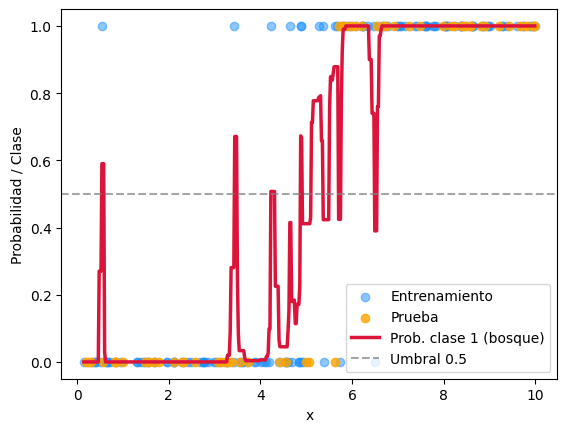

In [93]:
from sklearn.ensemble import RandomForestClassifier

n_datos = 200
x = np.random.rand(n_datos, 1) * 10
prob_verdadera = 1 / (1 + np.exp(-(x - 5)))
y = (prob_verdadera.ravel() + np.random.randn(n_datos) * 0.15 > 0.5).astype(int)

x_entrenamiento, x_prueba, y_entrenamiento, y_prueba = train_test_split(
    x, y, train_size=0.7, random_state=42
)

# Instanciar y entrenar
bosque_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
bosque_clf.fit(x_entrenamiento, y_entrenamiento)

# Predecir y evaluar
y_prediccion = bosque_clf.predict(x_prueba)
print(f"Accuracy: {accuracy_score(y_prueba, y_prediccion):.3f}")
print(confusion_matrix(y_prueba, y_prediccion))
print(classification_report(y_prueba, y_prediccion))

# Graficar: probabilidad estimada por el bosque
plt.scatter(x_entrenamiento, y_entrenamiento, color='dodgerblue', alpha=0.5, label='Entrenamiento')
plt.scatter(x_prueba, y_prueba, color='orange', alpha=0.8, label='Prueba')

x_linea = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)
prob_linea = bosque_clf.predict_proba(x_linea)[:, 1]
plt.plot(x_linea, prob_linea, color='crimson', linewidth=2.5, label='Prob. clase 1 (bosque)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral 0.5')

plt.legend()
plt.xlabel("x"); plt.ylabel("Probabilidad / Clase")
plt.show()